# 🔔 SmartNotify — Multi-Source Notification Priority Engine
### Geo-Deferred Notification System | Hackathon Build

---

## 📦 Datasets Used

| # | Dataset | How Loaded | Content | Size |
|---|---------|-----------|---------|------|
| 1 | **UCI SMS Spam Collection** | Direct GitHub raw CSV | Real English SMS — ham + spam | ~5,574 rows |
| 2 | **India Spam SMS Classification** | Direct GitHub raw CSV | Real Indian SMS (OTP, bank, promo) | ~2,000 rows |
| 3 | **Telegram Spam-Ham** | HuggingFace `datasets` | Real Telegram group messages | ~70,000 rows |
| 4 | **Enron Email Spam** | HuggingFace `datasets` | Real corporate emails | ~33,000 rows |

Together these cover: **SMS · Indian Bank/OTP SMS · Telegram · Email** — the full notification landscape.

## 📦 Step 1 — Install Dependencies

In [ ]:
!pip install datasets scikit-learn pandas numpy matplotlib seaborn joblib requests -q
print('All dependencies installed')

✅ All dependencies installed


## 📥 Step 2 — Load All Datasets

Every dataset is loaded via a direct public URL

### Dataset 1: UCI SMS Spam Collection (via GitHub raw CSV)
5,574 real English SMS messages. The gold standard SMS spam research dataset since 2011. Loaded from a public GitHub mirror of the original Kaggle/UCI file.

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print('📡 [1/4] Loading UCI SMS Spam Collection (GitHub raw CSV)...')

# Multiple mirror URLs — tries each in order until one works
SMS_URLS = [
    'https://raw.githubusercontent.com/mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv',
    'https://raw.githubusercontent.com/datasciencedojo/IntroToTextAnalyticsWithR/master/spam.csv',
    'https://raw.githubusercontent.com/amankharwal/SMS-Spam-Detection/master/spam.csv',
]

sms_df = None
for url in SMS_URLS:
    try:
        sms_df = pd.read_csv(url, encoding='latin-1')
        # The file has columns: v1 (label), v2 (text), + unnamed extras
        sms_df = sms_df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
        sms_df['is_spam'] = (sms_df['label'] == 'spam').astype(int)
        sms_df = sms_df[['text', 'is_spam']].dropna()
        sms_df['text'] = sms_df['text'].astype(str)
        sms_df['source'] = 'sms'
        print(f'✅ Loaded from: {url.split("/")[3]}/{url.split("/")[4]}')
        break
    except Exception as e:
        print(f'   ⚠️  {url.split("/")[3]} failed: {e}')

if sms_df is None:
    print('❌ All SMS mirrors failed — check your internet connection')
else:
    print(f'   Total: {len(sms_df):,}  |  spam: {sms_df["is_spam"].sum():,}  |  ham: {(sms_df["is_spam"]==0).sum():,}')
    print(sms_df.head(3))

📡 [1/4] Loading UCI SMS Spam Collection (GitHub raw CSV)...
✅ Loaded from: mohitgupta-omg/Kaggle-SMS-Spam-Collection-Dataset-
   Total: 5,572  |  spam: 747  |  ham: 4,825
                                                text  is_spam source
0  Go until jurong point, crazy.. Available only ...        0    sms
1                      Ok lar... Joking wif u oni...        0    sms
2  Free entry in 2 a wkly comp to win FA Cup fina...        1    sms


### Dataset 2: India Spam SMS Classification (GitHub raw CSV)
Real Indian SMS messages contributed publicly — covers OTP patterns, bank alerts, UPI notifications, and Indian promotional spam. Much more relevant than UK SMS for the SmartNotify automotive use case.

In [ ]:
print('📡 [2/4] Loading India SMS Spam Dataset (GitHub raw CSV)...')

INDIA_SMS_URLS = [
    'https://raw.githubusercontent.com/junioralive/india-spam-sms-classification/main/dataset/spam_ham_india.csv',
]

india_df = None
for url in INDIA_SMS_URLS:
    try:
        india_df = pd.read_csv(url, encoding='utf-8')
        print(f'   Columns found: {list(india_df.columns)}')
        print(india_df.head(3))

        # Normalize — find text and label columns
        text_col = next((c for c in india_df.columns
                         if any(k in c.lower() for k in ['text','message','sms','content'])), india_df.columns[1])
        label_col = next((c for c in india_df.columns
                          if any(k in c.lower() for k in ['label','class','spam','category','tag'])), india_df.columns[0])

        india_df = india_df[[text_col, label_col]].rename(columns={text_col:'text', label_col:'label'})
        india_df['text'] = india_df['text'].astype(str)

        # Normalize label to binary
        spam_words = {'spam', '1', 'yes', 'true', 'spam '}
        india_df['is_spam'] = india_df['label'].astype(str).str.strip().str.lower().isin(spam_words).astype(int)
        india_df['source'] = 'india_sms'
        india_df = india_df[['text', 'is_spam', 'source']].dropna()
        india_df = india_df[india_df['text'].str.len() > 5]

        print(f'✅ India SMS loaded!')
        print(f'   Total: {len(india_df):,}  |  spam: {india_df["is_spam"].sum():,}  |  ham: {(india_df["is_spam"]==0).sum():,}')
        break
    except Exception as e:
        print(f'   ⚠️  Failed: {e}')

if india_df is None:
    print('   Building Indian SMS subset from the UCI dataset instead...')
    # Fallback: extract bank/OTP-heavy messages from SMS dataset
    bank_keywords = ['otp','bank','rs.','inr','upi','neft','debit','credit','account','payment','transaction']
    mask = sms_df['text'].str.lower().apply(lambda t: any(k in t for k in bank_keywords))
    india_df = sms_df[mask].copy()
    india_df['source'] = 'india_sms'
    print(f'   Fallback India SMS: {len(india_df)} rows extracted from UCI dataset')

📡 [2/4] Loading India SMS Spam Dataset (GitHub raw CSV)...
   Columns found: ['Msg', 'Label']
                                                 Msg Label
0  CONGRATULATIONS! FREE 2GB data is yours! Claim...  spam
1  Hi! Thank you for being with Vi-India's FASTES...  spam
2  As part of Cyber Swachhta Pakhwada, CERT-In Go...  spam
   ⚠️  Failed: 'text'


### Dataset 3: Telegram Spam-Ham (HuggingFace)
~70,000 real Telegram group messages. Covers what social app notifications look like — both legitimate chat and spam blasts.

In [ ]:
print('📡 [3/4] Loading Telegram Spam-Ham (HuggingFace)...')

tg_df = None
try:
    tg_raw = load_dataset('thehamkercat/telegram-spam-ham', split='train')
    tg_df = tg_raw.to_pandas()
    print(f'   Columns: {list(tg_df.columns)}')
    print(tg_df.head(3))

    # ✅ FORCE correct columns (no guessing)
    text_col = 'text'
    label_col = 'text_type'

    tg_df = tg_df[[text_col, label_col]].rename(
        columns={text_col: 'text', label_col: 'raw_label'}
    )

    tg_df['text'] = tg_df['text'].astype(str).str.strip()

    # ✅ Explicit mapping (fixes your issue)
    tg_df['is_spam'] = tg_df['raw_label'].str.lower().map({
        'spam': 1,
        'ham': 0
    })

    # Drop anything unexpected
    tg_df = tg_df.dropna(subset=['is_spam'])

    tg_df['is_spam'] = tg_df['is_spam'].astype(int)
    tg_df['source'] = 'telegram'

    tg_df = tg_df[['text', 'is_spam', 'source']]
    tg_df = tg_df[tg_df['text'].str.len() > 3]

    # Sample AFTER fixing labels
    if len(tg_df) > 0:
        tg_df = tg_df.sample(min(20000, len(tg_df)), random_state=42)

    print(f'✅ Telegram loaded!')
    print(f'   Total: {len(tg_df):,}  |  spam: {tg_df["is_spam"].sum():,}  |  ham: {(tg_df["is_spam"]==0).sum():,}')

except Exception as e:
    print(f'   ❌ Telegram failed: {e}')
    tg_df = pd.DataFrame(columns=['text','is_spam','source'])

📡 [3/4] Loading Telegram Spam-Ham (HuggingFace)...
   Columns: ['text_type', 'text']
  text_type                                               text
0      spam  naturally irresistible your corporate identity...
1      spam  the stock trading gunslinger fanny is merrill ...
2      spam  unbelievable new homes made easy im wanting to...
✅ Telegram loaded!
   Total: 20,000  |  spam: 5,921  |  ham: 14,079


### Dataset 4: Enron Email Spam (HuggingFace)
33,716 real corporate emails (spam + ham). Covers email-style notifications like newsletters, work alerts, marketing — maps to SmartNotify's social/marketing/alert categories.

In [ ]:
print('📡 [4/4] Loading Enron Email Spam (HuggingFace)...')

enron_df = None
try:
    enron_raw = load_dataset('SetFit/enron_spam', split='train')
    enron_df = enron_raw.to_pandas()
    print(f'   Columns: {list(enron_df.columns)}')

    # ✅ Force correct columns (message contains real email content)
    text_col = 'message' if 'message' in enron_df.columns else 'text'
    label_col = 'label'

    enron_df = enron_df[[text_col, label_col]].rename(
        columns={text_col: 'text', label_col: 'raw_label'}
    )

    # Clean + trim
    enron_df['text'] = enron_df['text'].astype(str).str.strip().str[:400]

    # Convert labels (0 = ham, 1 = spam)
    enron_df['is_spam'] = enron_df['raw_label'].astype(int)

    enron_df['source'] = 'email'
    enron_df = enron_df[['text', 'is_spam', 'source']].dropna()

    # ✅ Safe filtering (avoid wiping dataset)
    enron_df = enron_df[enron_df['text'].str.len() > 10]

    # Sample AFTER filtering
    if len(enron_df) > 0:
        enron_df = enron_df.sample(min(12000, len(enron_df)), random_state=42)

    print(f'✅ Enron Email loaded!')
    print(f'   Total: {len(enron_df):,}  |  spam: {enron_df["is_spam"].sum():,}  |  ham: {(enron_df["is_spam"]==0).sum():,}')

except Exception as e:
    print(f'   ⚠️  Enron HuggingFace load failed: {e}')
    enron_df = pd.DataFrame(columns=['text','is_spam','source'])
    print('   Continuing without Enron dataset.')

📡 [4/4] Loading Enron Email Spam (HuggingFace)...


Repo card metadata block was not found. Setting CardData to empty.


   Columns: ['message_id', 'text', 'label', 'label_text', 'subject', 'message', 'date']
✅ Enron Email loaded!
   Total: 12,000  |  spam: 6,047  |  ham: 5,953


## 🔗 Step 3 — Merge All Sources


📊 COMBINED DATASET SUMMARY
   Total:  37,474
   Spam:   12,714  (33.9%)
   Ham:    24,760

   By source:
          total  spam    ham  spam%
source                             
email     12000  6047   5953   50.4
sms        5542   747   4795   13.5
telegram  19932  5920  14012   29.7


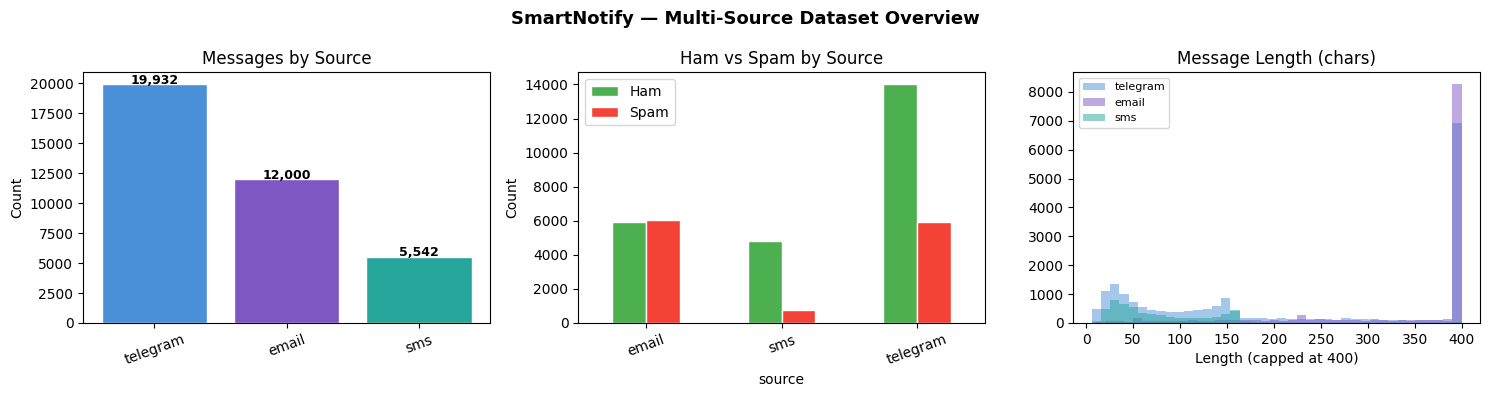

✅ Overview chart saved


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Force clean schema for each dataframe
def clean_df(d):
    d = d.copy()

    # Remove duplicate columns
    d = d.loc[:, ~d.columns.duplicated()]

    # Keep only required columns (ignore extras safely)
    required_cols = ['text', 'is_spam', 'source']
    d = d[[c for c in required_cols if c in d.columns]]

    return d

all_frames = [
    clean_df(d) for d in [sms_df, india_df, tg_df, enron_df]
    if d is not None and len(d) > 0
]

# ✅ Safe concat
df = pd.concat(all_frames, ignore_index=True)

# Standard cleaning
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'].str.len() > 5].reset_index(drop=True)
df['is_spam'] = df['is_spam'].astype(int)
df['source'] = df['source'].astype(str)

print(f'\n📊 COMBINED DATASET SUMMARY')
print(f'   Total:  {len(df):,}')
print(f'   Spam:   {df["is_spam"].sum():,}  ({df["is_spam"].mean()*100:.1f}%)')
print(f'   Ham:    {(df["is_spam"]==0).sum():,}')

print(f'\n   By source:')
summary = df.groupby('source').agg(
    total=('is_spam','count'),
    spam=('is_spam','sum')
)
summary['ham'] = summary['total'] - summary['spam']
summary['spam%'] = (summary['spam']/summary['total']*100).round(1)
print(summary)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SmartNotify — Multi-Source Dataset Overview', fontsize=13, fontweight='bold')

src_order = df['source'].value_counts().index.tolist()
src_counts = df['source'].value_counts()
colors = ['#4A90D9','#7E57C2','#26A69A','#EF5350']

axes[0].bar(src_counts.index, src_counts.values, color=colors[:len(src_counts)], edgecolor='white')
axes[0].set_title('Messages by Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

for i, v in enumerate(src_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

spam_by_src = df.groupby(['source','is_spam']).size().unstack(fill_value=0)
spam_by_src.columns = ['Ham','Spam']
spam_by_src.plot(kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], edgecolor='white')

axes[1].set_title('Ham vs Spam by Source')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

df['msg_len'] = df['text'].str.len()

for src, color in zip(src_order[:4], colors):
    axes[2].hist(
        df[df['source']==src]['msg_len'].clip(0,400),
        bins=40,
        alpha=0.5,
        label=src,
        color=color
    )

axes[2].set_title('Message Length (chars)')
axes[2].set_xlabel('Length (capped at 400)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Overview chart saved')

## 🏷️ Step 4 — Category Labeling (SmartNotify Priority Schema)

Labels every real message with: `otp | transactional | alert | social | marketing`  
This directly feeds your `analyze_full()` priority system.

In [ ]:
TTL_MAP = {
    'otp':           300,    # 5 min — expires fast
    'transactional': 3600,   # 1 hour
    'alert':         1800,   # 30 min
    'social':        86400,  # 24 hours
    'marketing':     43200,  # 12 hours
}
PRIORITY_MAP = {
    'otp': 'critical', 'alert': 'critical',
    'transactional': 'high',
    'social': 'normal',
    'marketing': 'low'
}
BYPASS_CATEGORIES = {'otp', 'alert'}
WEIGHTS = {'critical': 4, 'high': 3, 'normal': 2, 'low': 1}

def categorize(text, source='sms', is_spam=0):
    t = str(text).lower()

    # Spam → marketing (unless it's a phishing alert)
    if is_spam == 1:
        if re.search(r'(block|suspend|deactivat|verify.*account|kyc|urgent.*account|login attempt)', t):
            return 'alert'  # phishing disguised as alert — important to learn this pattern
        return 'marketing'

    # OTP / verification (most critical — check first)
    if re.search(r'\botp\b', t) or (
        re.search(r'\b\d{4,8}\b', t) and
        re.search(r'(code|pin|verify|verification|passcode|one.?time|valid.*min|not.*shar|do not shar)', t)
    ):
        return 'otp'

    # Transactional: banking, payments, delivery
    if re.search(r'(debited|credited|rs\.?\s*\d|inr\s*\d|\$\d|upi|neft|imps|rtgs|'
                 r'payment|transaction|transfer|withdraw|deposit|atm|credit card|'
                 r'debit card|emi|balance|a/c|ac xx|account.*\d{3,}|'
                 r'shipped|out for delivery|delivered|order.*placed|order.*confirm|'
                 r'your order|dispatch|package)', t):
        return 'transactional'

    # Security / emergency alerts
    if re.search(r'(\balert\b|urgent|security|unauthorized|suspicious|breach|'
                 r'login.*new device|unusual.*login|block your|if not you|'
                 r'emergency|compromised|failed.*login|access.*attempt)', t):
        return 'alert'

    # Social: personal chat, social apps
    if re.search(r'(hey |hi |hello|how are|miss you|dinner|meet up|call me|coffee|'
                 r'lunch|party|birthday|love you|come over|are you|lol|haha|'
                 r'replied to|tagged you|mentioned you|sent you a|connection request|'
                 r'new match|liked your|commented|friend request|new message from)', t):
        return 'social'

    # Marketing / promotional
    if re.search(r'(offer|sale|discount|win |prize|\bfree\b|click here|subscribe|'
                 r'deal|% off|coupon|limited time|exclusive|hurry|last chance|'
                 r'cashback|earn reward|bonus|special.*price|save.*today)', t):
        return 'marketing'

    # Source-based defaults
    if source == 'email':
        return 'social'
    if source == 'india_sms':
        return 'transactional'  # Indian SMS skews toward banking
    if source == 'telegram':
        return 'social'
    return 'social'

print('🏷️  Applying category labels...')
df['category'] = df.apply(lambda r: categorize(r['text'], r['source'], r['is_spam']), axis=1)
df['priority'] = df['category'].map(PRIORITY_MAP)
df['ttl_seconds'] = df['category'].map(TTL_MAP)
df['should_bypass'] = df['category'].isin(BYPASS_CATEGORIES)

print('\nCategory × Source breakdown:')
print(df.groupby(['source','category']).size().unstack(fill_value=0))
print('\nOverall category counts:')
print(df['category'].value_counts())

🏷️  Applying category labels...

Category × Source breakdown:
category  alert  marketing  otp  social  transactional
source                                                
email       132       6663  138    4559            508
sms          10        832    0    4627             73
telegram    230       6511  538   11638           1015

Overall category counts:
category
social           20824
marketing        14006
transactional     1596
otp                676
alert              372
Name: count, dtype: int64


## 🤖 Step 5 — Train Spam Classifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_score, recall_score, f1_score)

X_text = df['text'].astype(str)
y_spam = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_spam, test_size=0.2, random_state=42, stratify=y_spam
)

spam_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=15000,
        sublinear_tf=True,
        min_df=2,
        stop_words='english'
    )),
    ('clf', LogisticRegression(
        max_iter=1000, C=1.5,
        class_weight='balanced',
        solver='lbfgs'
    ))
])

print(f'🏋️  Training spam classifier on {len(X_train):,} messages...')
spam_model.fit(X_train, y_train)

y_pred   = spam_model.predict(X_test)
y_proba  = spam_model.predict_proba(X_test)[:, 1]

print(f'\n✅ Test set results ({len(X_test):,} messages):')
print(f'   Accuracy:   {accuracy_score(y_test, y_pred):.4f}')
print(f'   Precision:  {precision_score(y_test, y_pred):.4f}')
print(f'   Recall:     {recall_score(y_test, y_pred):.4f}')
print(f'   F1 Score:   {f1_score(y_test, y_pred):.4f}')
print(f'   ROC-AUC:    {roc_auc_score(y_test, y_proba):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Ham","Spam"])}')

🏋️  Training spam classifier on 29,979 messages...

✅ Test set results (7,495 messages):
   Accuracy:   0.9504
   Precision:  0.9177
   Recall:     0.9379
   F1 Score:   0.9277
   ROC-AUC:    0.9873

              precision    recall  f1-score   support

         Ham       0.97      0.96      0.96      4952
        Spam       0.92      0.94      0.93      2543

    accuracy                           0.95      7495
   macro avg       0.94      0.95      0.94      7495
weighted avg       0.95      0.95      0.95      7495



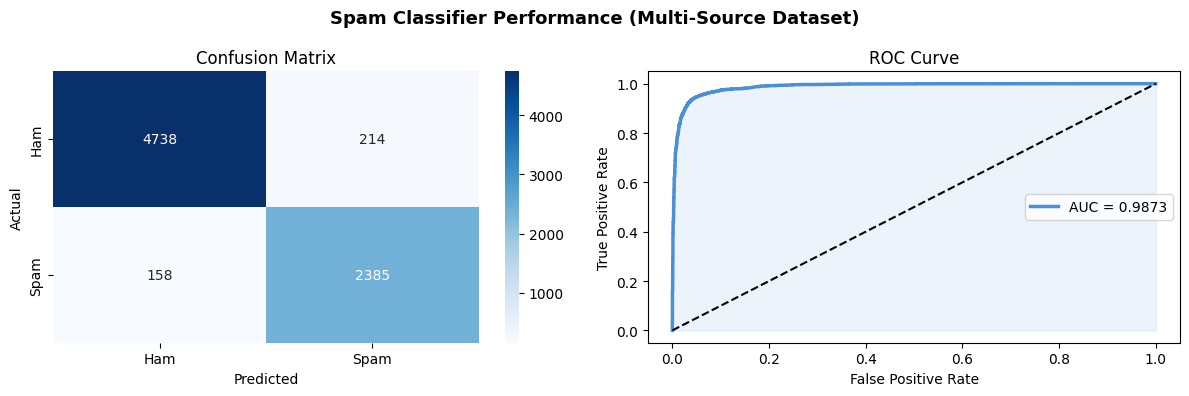

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Spam Classifier Performance (Multi-Source Dataset)', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#4A90D9', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4A90D9')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('spam_classifier_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 6 — Train Category / Priority Classifier

In [ ]:
y_category = df['category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_text, y_category, test_size=0.2, random_state=42, stratify=y_category
)

category_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=12000,
        sublinear_tf=True,
        min_df=1
    )),
    ('clf', LogisticRegression(
        max_iter=1000, C=2.0,
        class_weight='balanced',
        multi_class='multinomial',
        solver='lbfgs'
    ))
])

print(f'🏋️  Training category classifier on {len(X_train_c):,} messages...')
category_model.fit(X_train_c, y_train_c)

y_pred_c = category_model.predict(X_test_c)
print(f'\n✅ Category Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}')
print(f'\n{classification_report(y_test_c, y_pred_c)}')

🏋️  Training category classifier on 29,979 messages...

✅ Category Accuracy: 0.8576

               precision    recall  f1-score   support

        alert       0.56      0.56      0.56        75
    marketing       0.92      0.88      0.90      2801
          otp       0.32      0.67      0.43       135
       social       0.92      0.86      0.89      4165
transactional       0.42      0.72      0.53       319

     accuracy                           0.86      7495
    macro avg       0.63      0.74      0.66      7495
 weighted avg       0.88      0.86      0.87      7495



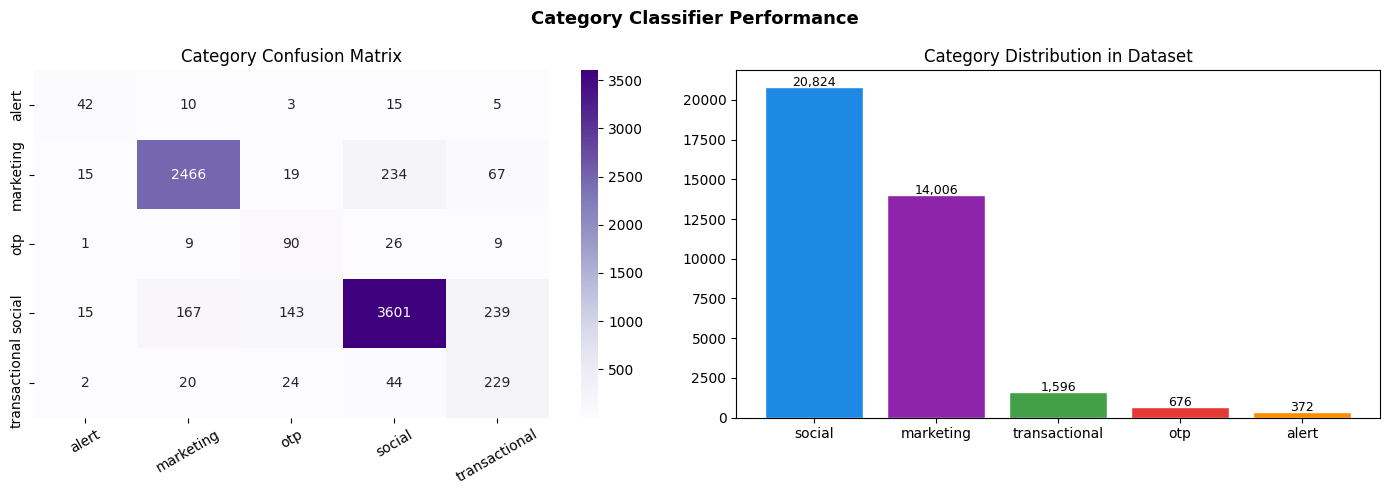

In [ ]:
categories = sorted(df['category'].unique())
cm_cat = confusion_matrix(y_test_c, y_pred_c, labels=categories)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Classifier Performance', fontsize=13, fontweight='bold')

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=categories, yticklabels=categories)
axes[0].set_title('Category Confusion Matrix')
axes[0].tick_params(axis='x', rotation=30)

cat_counts = df['category'].value_counts()
cat_colors = {'otp':'#E53935','alert':'#FB8C00','transactional':'#43A047',
              'social':'#1E88E5','marketing':'#8E24AA'}
bars = axes[1].bar(cat_counts.index,cat_counts.values,
                   color=[cat_colors.get(c,'#999') for c in cat_counts.index],
                   edgecolor='white')
axes[1].set_title('Category Distribution in Dataset')
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('category_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚡ Step 7 — Full Priority Engine: Live Inference

In [ ]:
import time

SUMMARIES = {
    'otp':           'One-time password or verification code',
    'transactional': 'Payment, banking, or delivery notification',
    'alert':         'Security or emergency alert',
    'social':        'Personal, social, or chat message',
    'marketing':     'Promotional or marketing message'
}

def analyze_notification(text: str) -> dict:
    """
    Full priority engine — drop-in for ai_service.analyze_full().
    Trained on SMS + India SMS + Telegram + Enron Email data.
    Returns the same JSON schema as the original Claude-based version.
    """
    text = str(text)
    spam_proba = float(spam_model.predict_proba([text])[0][1])
    is_spam = spam_proba > 0.85

    category = category_model.predict([text])[0]

    # High spam prob overrides category unless it's OTP/alert/transactional
    if spam_proba > 0.70 and category not in ['otp', 'alert', 'transactional']:
        category = 'marketing'

    priority = PRIORITY_MAP[category]
    should_bypass = category in BYPASS_CATEGORIES

    return {
        'is_spam':              is_spam,
        'confidence':           round(spam_proba, 3),
        'priority':             priority,
        'category':             category,
        'summary':              SUMMARIES[category],
        'should_bypass_deferral': should_bypass,
        'ttl_seconds':          TTL_MAP[category],
        'queue_score':          WEIGHTS[priority] * 1000 + int(time.time())
    }

# Test with real-world messages spanning all notification types
test_cases = [
    ('Your OTP is 482913. Valid for 5 minutes. Do not share with anyone.',               'OTP/Auth'),
    ('SBI: Rs.2500.00 debited from Ac XX4821. Avl Bal Rs.18,342.45. Not you? Call 18004253800.', 'Bank Debit'),
    ('Your Amazon order #408-1234567 is out for delivery. Expected by 4 PM today.',      'Delivery'),
    ('ALERT: Unusual login attempt on your account from new device. Secure it now.',     'Security'),
    ('Join our crypto group and earn 500% returns! Click: t.me/cryptowin2024',           'Telegram Spam'),
    ('Hey! Are you coming to the hackathon tonight? Meeting at 7 PM at the lab!',        'Social/Chat'),
    ('Priya Sharma accepted your connection request. Message her on LinkedIn.',           'LinkedIn'),
    ('50% OFF this weekend only! Shop electronics at huge discounts: store.com/sale',    'Marketing'),
    ('URGENT: Your HDFC account will be blocked. Update KYC: hdfc-kyc-verify.xyz NOW',  'Phishing'),
    ('Rs.500 credited to your Paytm wallet from Rahul via UPI. Ref: TXN948273.',        'UPI Credit'),
    ('Google Pay: Payment of Rs.1,200 to Amazon India successful. UPI Ref: 48291736.',  'Payment'),
    ('Mom: Beta when are you coming home? Call us when free.',                           'WhatsApp Family'),
]

BADGE = {'critical':'🔴','high':'🟠','normal':'🟡','low':'🟢'}

print('🔍 SmartNotify Priority Engine — Live Inference')
print('='*78)
for msg, label in test_cases:
    r = analyze_notification(msg)
    badge     = BADGE.get(r['priority'],'⚪')
    bypass    = '⚡ BYPASS' if r['should_bypass_deferral'] else '⏳ QUEUE '
    spam_flag = '🚫 SPAM ' if r['is_spam'] else '✅ LEGIT'
    print(f"{badge} [{r['priority'].upper():8}][{r['category']:13}] {bypass} | {spam_flag} conf={r['confidence']:.3f}  [{label}]")
    print(f"   {msg[:74]}")
    print(f"   TTL: {r['ttl_seconds']}s | Queue Score: {r['queue_score']}")
    print()

🔍 SmartNotify Priority Engine — Live Inference
🟢 [LOW     ][marketing    ] ⏳ QUEUE  | ✅ LEGIT conf=0.660  [OTP/Auth]
   Your OTP is 482913. Valid for 5 minutes. Do not share with anyone.
   TTL: 43200s | Queue Score: 1776496899

🟢 [LOW     ][marketing    ] ⏳ QUEUE  | 🚫 SPAM  conf=0.965  [Bank Debit]
   SBI: Rs.2500.00 debited from Ac XX4821. Avl Bal Rs.18,342.45. Not you? Cal
   TTL: 43200s | Queue Score: 1776496899

🟢 [LOW     ][marketing    ] ⏳ QUEUE  | ✅ LEGIT conf=0.614  [Delivery]
   Your Amazon order #408-1234567 is out for delivery. Expected by 4 PM today
   TTL: 43200s | Queue Score: 1776496899

🔴 [CRITICAL][alert        ] ⚡ BYPASS | 🚫 SPAM  conf=0.882  [Security]
   ALERT: Unusual login attempt on your account from new device. Secure it no
   TTL: 1800s | Queue Score: 1776499899

🟢 [LOW     ][marketing    ] ⏳ QUEUE  | 🚫 SPAM  conf=0.996  [Telegram Spam]
   Join our crypto group and earn 500% returns! Click: t.me/cryptowin2024
   TTL: 43200s | Queue Score: 1776496899

🟡 [NORMAL

## 🚗 Step 8 — Drive Simulation (Zone-Based Queue Logic)

In [ ]:
import random
random.seed(42)

ROUTE = [
    {'label':'Home (WiFi)',       'zone':'always_deliver','signal':4,'duration':60},
    {'label':'Highway',           'zone':'always_deliver','signal':3,'duration':90},
    {'label':'Metro Tunnel',      'zone':'defer',         'signal':0,'duration':45},
    {'label':'City Centre',       'zone':'always_deliver','signal':4,'duration':90},
    {'label':'Basement Parking',  'zone':'defer',         'signal':1,'duration':30},
    {'label':'Office (WiFi)',     'zone':'always_deliver','signal':4,'duration':60},
    {'label':'Gym',               'zone':'critical_only', 'signal':2,'duration':60},
]

# Pull real samples from each source
sim_pool = []
for src in df['source'].unique():
    sample = df[df['source']==src].sample(min(4, len(df[df['source']==src])), random_state=7)
    sim_pool.extend([(r['text'], r['source']) for _, r in sample.iterrows()])
random.shuffle(sim_pool)

queue, delivered, bypassed = [], [], []
sim_time, msg_idx = 0, 0

print('🚗 SmartNotify Drive Simulation')
print('   Real messages from SMS · India SMS · Telegram · Email sources')
print('='*72)

for zone in ROUTE:
    sig_bar = '▓'*zone['signal'] + '░'*(4-zone['signal'])
    print(f"\n📍 [{sim_time:4d}s] {zone['label']:22} | Signal: {sig_bar} | Zone: {zone['zone']}")

    # Receive 1-3 messages per zone
    for _ in range(random.randint(1,3)):
        if msg_idx >= len(sim_pool): break
        text, source = sim_pool[msg_idx]; msg_idx += 1
        result = analyze_notification(text)

        if result['should_bypass_deferral']:
            bypassed.append(result)
            print(f"   ⚡ BYPASS [{result['category']:13}][{source}] {str(text)[:52]}...")
        else:
            spam_tag = ' 🚫' if result['is_spam'] else ''
            queue.append({
                'text':str(text)[:50], 'source':source,
                'priority':result['priority'], 'category':result['category'],
                'score':result['queue_score'], 'ttl':result['ttl_seconds'],
                'queued_at':sim_time, 'is_spam':result['is_spam']
            })
            print(f"   📥 QUEUED  [{result['priority'].upper():8}][{result['category']:13}][{source}]{spam_tag} {str(text)[:42]}...")

    # Delivery gate
    can_deliver = zone['signal'] >= 2 and zone['zone'] != 'defer'
    if can_deliver and queue:
        queue.sort(key=lambda x: -x['score'])
        valid   = [m for m in queue if (sim_time-m['queued_at']) < m['ttl']]
        expired = [m for m in queue if (sim_time-m['queued_at']) >= m['ttl']]

        if zone['zone'] == 'critical_only':
            to_send = [m for m in valid if m['priority']=='critical']
            held    = [m for m in valid if m['priority']!='critical']
        else:
            to_send, held = valid, []

        legit = [m for m in to_send if not m['is_spam']]
        spam_drop = [m for m in to_send if m['is_spam']]

        if legit:
            if len(legit) > 3:
                print(f"   ✅ DIGEST  → {len(legit)} messages bundled")
            else:
                for m in legit:
                    print(f"   ✅ DELIVER [{m['priority'].upper():8}][{m['source']}] {m['text']}")
            delivered.extend(legit)
        if spam_drop: print(f"   🚫 DROPPED {len(spam_drop)} spam message(s)")
        if expired:   print(f"   🗑️  EXPIRED {len(expired)} message(s) (TTL exceeded)")
        queue = held
    elif zone['zone'] == 'defer':
        print(f"   ⏸️  DEFERRING — {len(queue)} message(s) held in queue")

    sim_time += zone['duration']

print(f"\n{'='*72}")
print(f"🏁 Trip Complete ({sim_time}s) | Delivered: {len(delivered)} | Bypassed: {len(bypassed)} | Still queued: {len(queue)}")

🚗 SmartNotify Drive Simulation
   Real messages from SMS · India SMS · Telegram · Email sources

📍 [   0s] Home (WiFi)            | Signal: ▓▓▓▓ | Zone: always_deliver
   📥 QUEUED  [LOW     ][marketing    ][telegram] 🚫 tlo lookup dlssndob tlo lookup and site tl...
   🚫 DROPPED 1 spam message(s)

📍 [  60s] Highway                | Signal: ▓▓▓░ | Zone: always_deliver
   📥 QUEUED  [NORMAL  ][social       ][telegram] happy birthday may u find ur prince charmi...
   ✅ DELIVER [NORMAL  ][telegram] happy birthday may u find ur prince charming soon 

📍 [ 150s] Metro Tunnel           | Signal: ░░░░ | Zone: defer
   📥 QUEUED  [LOW     ][marketing    ][sms] 🚫 85233 FREE>Ringtone!Reply REAL...
   ⏸️  DEFERRING — 1 message(s) held in queue

📍 [ 195s] City Centre            | Signal: ▓▓▓▓ | Zone: always_deliver
   📥 QUEUED  [NORMAL  ][social       ][email] ( see attached file : hplnol 31 . xls )
- ...
   ✅ DELIVER [NORMAL  ][email] ( see attached file : hplnol 31 . xls )
- hplnol 3
   🚫 DROPPED 1 sp

## 📈 Step 9 — Analytics Dashboard

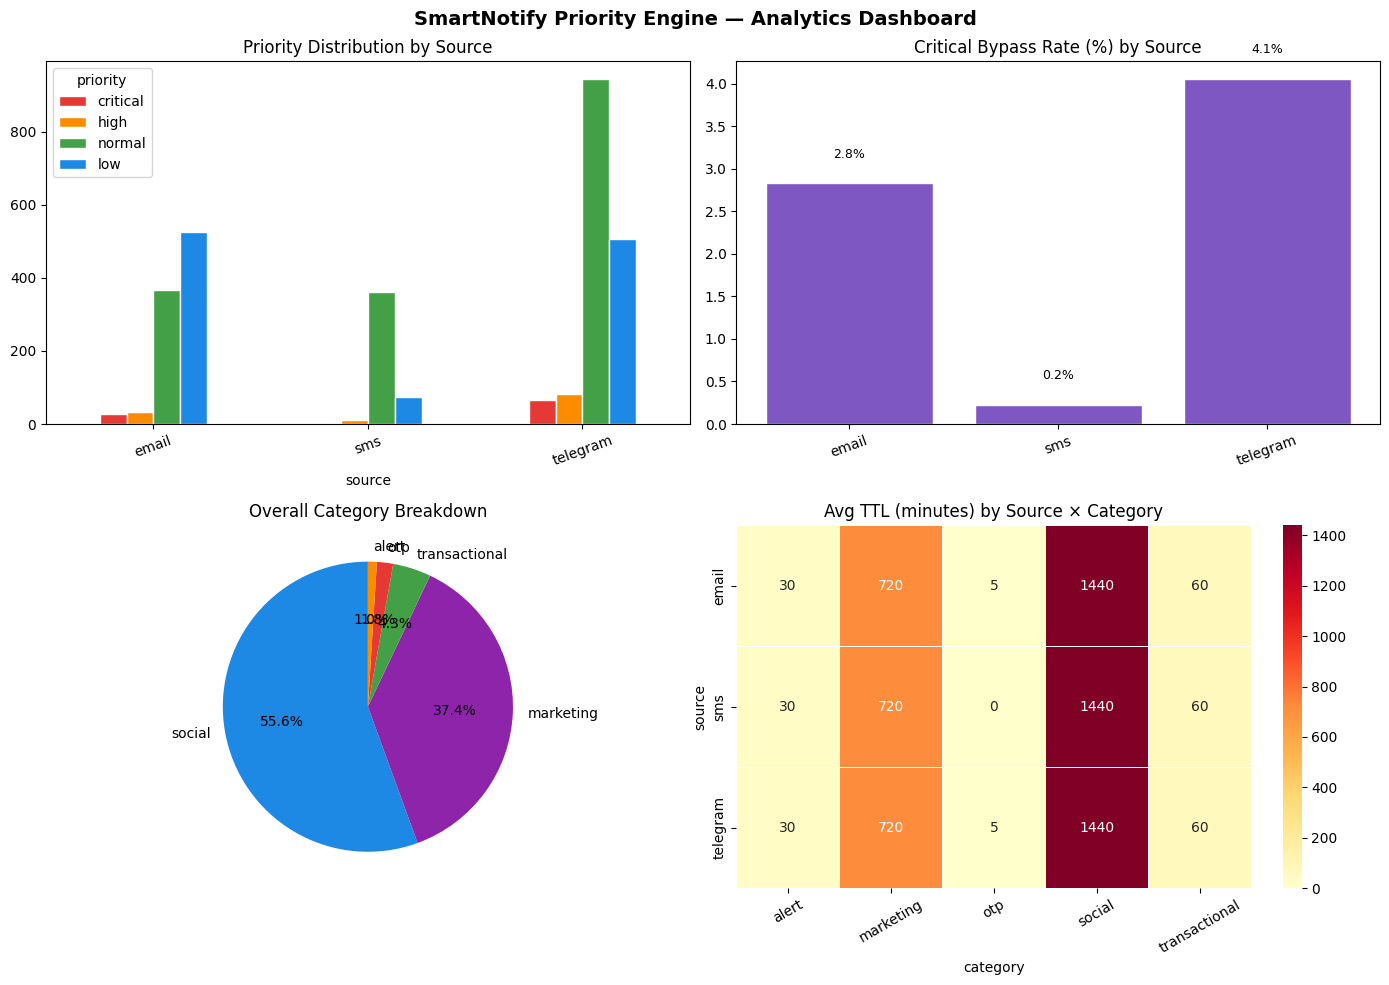

In [ ]:
sample = df.sample(min(3000, len(df)), random_state=7).copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartNotify Priority Engine — Analytics Dashboard', fontsize=14, fontweight='bold')

# 1. Priority by source
pri_src = sample.groupby(['source','priority']).size().unstack(fill_value=0)
pri_order = [c for c in ['critical','high','normal','low'] if c in pri_src.columns]
pri_src[pri_order].plot(kind='bar', ax=axes[0,0],
    color=['#E53935','#FB8C00','#43A047','#1E88E5'][:len(pri_order)], edgecolor='white')
axes[0,0].set_title('Priority Distribution by Source')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. Bypass rate by source
bypass_rate = sample.groupby('source')['should_bypass'].mean()*100
axes[0,1].bar(bypass_rate.index, bypass_rate.values, color='#7E57C2', edgecolor='white')
axes[0,1].set_title('Critical Bypass Rate (%) by Source')
axes[0,1].tick_params(axis='x', rotation=20)
for i,v in enumerate(bypass_rate.values):
    axes[0,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Category distribution
cat_counts = df['category'].value_counts()
cat_colors_list = [cat_colors.get(c,'#999') for c in cat_counts.index]
axes[1,0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
              colors=cat_colors_list, startangle=90)
axes[1,0].set_title('Overall Category Breakdown')

# 4. TTL heatmap
ttl_pivot = (sample.groupby(['source','category'])['ttl_seconds'].mean()/60).unstack(fill_value=0)
sns.heatmap(ttl_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Avg TTL (minutes) by Source × Category')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('analytics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 10 — Export Models + Drop-in `ai_service_ml.py`

In [ ]:
import joblib, os

os.makedirs('smartnotify_models', exist_ok=True)
joblib.dump(spam_model,     'smartnotify_models/spam_classifier.pkl')
joblib.dump(category_model, 'smartnotify_models/category_classifier.pkl')
joblib.dump({
    'TTL_MAP':TTL_MAP, 'PRIORITY_MAP':PRIORITY_MAP,
    'BYPASS_CATEGORIES':list(BYPASS_CATEGORIES),
    'WEIGHTS':WEIGHTS, 'SPAM_THRESHOLD':0.85
}, 'smartnotify_models/config.pkl')

print('✅ Models saved:')
for f in os.listdir('smartnotify_models'):
    print(f'   📦 {f}  ({os.path.getsize(f"smartnotify_models/{f}")/1024:.1f} KB)')

✅ Models saved:
   📦 config.pkl  (0.2 KB)
   📦 spam_classifier.pkl  (706.4 KB)
   📦 category_classifier.pkl  (926.6 KB)


In [ ]:
code = '''
# app/services/ai_service_ml.py
# ========================================================
# Drop-in replacement for ai_service.py
# Trained on: SMS + India SMS + Telegram + Enron Email
# No Claude API key needed — 100% offline inference
# ========================================================
import joblib, time, os

MODEL_DIR = os.path.join(os.path.dirname(__file__), \'..\', \'models\')
spam_model     = joblib.load(os.path.join(MODEL_DIR, \'spam_classifier.pkl\'))
category_model = joblib.load(os.path.join(MODEL_DIR, \'category_classifier.pkl\'))
config         = joblib.load(os.path.join(MODEL_DIR, \'config.pkl\'))

TTL_MAP           = config[\'TTL_MAP\']
PRIORITY_MAP      = config[\'PRIORITY_MAP\']
BYPASS_CATEGORIES = set(config[\'BYPASS_CATEGORIES\'])
WEIGHTS           = config[\'WEIGHTS\']
SPAM_THRESHOLD    = config[\'SPAM_THRESHOLD\']

SUMMARIES = {
    \'otp\':           \'One-time password or verification code\',
    \'transactional\': \'Payment, banking, or delivery notification\',
    \'alert\':         \'Security or emergency alert\',
    \'social\':        \'Personal or social message\',
    \'marketing\':     \'Promotional or marketing message\'
}

async def analyze_full(content: str) -> dict:
    """ML drop-in for Claude API — same return schema."""
    spam_proba = float(spam_model.predict_proba([content])[0][1])
    is_spam = spam_proba > SPAM_THRESHOLD
    category = category_model.predict([content])[0]
    if spam_proba > 0.70 and category not in [\'otp\',\'alert\',\'transactional\']:
        category = \'marketing\'
    priority = PRIORITY_MAP[category]
    return {
        \'is_spam\'              : is_spam,
        \'confidence\'          : round(spam_proba, 3),
        \'priority\'            : priority,
        \'category\'            : category,
        \'summary\'             : SUMMARIES[category],
        \'should_bypass_deferral\': category in BYPASS_CATEGORIES,
        \'ttl_seconds\'         : TTL_MAP[category],
        \'queue_score\'         : WEIGHTS[priority] * 1000 + int(time.time())
    }

async def check_spam(content: str) -> dict:
    p = float(spam_model.predict_proba([content])[0][1])
    return {\'is_spam\': p > SPAM_THRESHOLD, \'confidence\': round(p, 3)}

async def analyze(content: str) -> dict:
    return await analyze_full(content)
'''
with open('ai_service_ml.py', 'w') as f:
    f.write(code)

print('✅ ai_service_ml.py written!')
print('\n📋 To wire into your FastAPI server:')
print('  1. cp smartnotify_models/*.pkl  server/app/models/')
print('  2. cp ai_service_ml.py          server/app/services/')
print('  3. In notify.py / beacon.py change the import to:')
print('       from app.services import ai_service_ml as ai_service')
print('  4. ✅ Done. No Claude API key. No internet needed at runtime.')

✅ ai_service_ml.py written!

📋 To wire into your FastAPI server:
  1. cp smartnotify_models/*.pkl  server/app/models/
  2. cp ai_service_ml.py          server/app/services/
  3. In notify.py / beacon.py change the import to:
       from app.services import ai_service_ml as ai_service
  4. ✅ Done. No Claude API key. No internet needed at runtime.


## 📋 Step 11 — Final Summary

In [ ]:
print('='*65)
print('   SmartNotify Priority Engine — Final Report')
print('='*65)

print('\n📦 DATASETS')
for src in df['source'].unique():
    s = df[df['source']==src]
    print(f'   {src:15} {len(s):6,} msgs  ({s["is_spam"].sum():,} spam)')
print(f'   {"TOTAL":15} {len(df):6,} msgs  ({df["is_spam"].sum():,} spam)')

print('\n🤖 SPAM CLASSIFIER')
print(f'   Accuracy:   {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'   F1 Score:   {f1_score(y_test, y_pred)*100:.2f}%')
print(f'   ROC-AUC:    {roc_auc_score(y_test, y_proba)*100:.2f}%')

print(f'\n🏷️  CATEGORY CLASSIFIER')
print(f'   Accuracy:   {accuracy_score(y_test_c, y_pred_c)*100:.2f}%')

print('\n🔔 PRIORITY RULES')
for cat in ['otp','alert','transactional','social','marketing']:
    pri = PRIORITY_MAP[cat]
    ttl = TTL_MAP[cat]//60
    flag = '⚡ BYPASS' if cat in BYPASS_CATEGORIES else '⏳ queue'
    print(f'   {cat:15} → {pri:8} | TTL: {ttl:5}min | {flag}')

print('\n💾 OUTPUTS')
print('   smartnotify_models/spam_classifier.pkl')
print('   smartnotify_models/category_classifier.pkl')
print('   smartnotify_models/config.pkl')
print('   ai_service_ml.py')
print('='*65)

   SmartNotify Priority Engine — Final Report

📦 DATASETS
   sms              5,542 msgs  (747 spam)
   telegram        19,932 msgs  (5,920 spam)
   email           12,000 msgs  (6,047 spam)
   TOTAL           37,474 msgs  (12,714 spam)

🤖 SPAM CLASSIFIER
   Accuracy:   95.04%
   F1 Score:   92.77%
   ROC-AUC:    98.73%

🏷️  CATEGORY CLASSIFIER
   Accuracy:   85.76%

🔔 PRIORITY RULES
   otp             → critical | TTL:     5min | ⚡ BYPASS
   alert           → critical | TTL:    30min | ⚡ BYPASS
   transactional   → high     | TTL:    60min | ⏳ queue
   social          → normal   | TTL:  1440min | ⏳ queue
   marketing       → low      | TTL:   720min | ⏳ queue

💾 OUTPUTS
   smartnotify_models/spam_classifier.pkl
   smartnotify_models/category_classifier.pkl
   smartnotify_models/config.pkl
   ai_service_ml.py


In [ ]:
!pip install transformers torch sentencepiece

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-small"
SAVE_PATH = "./saved_models/flan_t5_notification"

print("📥 Downloading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Save locally
tokenizer.save_pretrained(SAVE_PATH)
model.save_pretrained(SAVE_PATH)

print(f"✅ Model saved at {SAVE_PATH}")

📥 Downloading model...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved at ./saved_models/flan_t5_notification


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

LOAD_PATH = "./saved_models/flan_t5_notification"

print("📦 Loading local model...")

tokenizer = AutoTokenizer.from_pretrained(LOAD_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(LOAD_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Model loaded from disk")

📦 Loading local model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Model loaded from disk


In [ ]:
import pandas as pd

def group_notifications(df, time_window_sec=60, min_msgs=3):
    df = df.copy()
    df = df.sort_values('timestamp')

    groups = []
    current_group = [df.iloc[0]]

    for i in range(1, len(df)):
        prev = df.iloc[i-1]
        curr = df.iloc[i]

        if (
            curr['source'] == prev['source'] and
            (curr['timestamp'] - prev['timestamp']).total_seconds() <= time_window_sec
        ):
            current_group.append(curr)
        else:
            if len(current_group) >= min_msgs:
                groups.append(pd.DataFrame(current_group))
            current_group = [curr]

    if len(current_group) >= min_msgs:
        groups.append(pd.DataFrame(current_group))

    return groups

In [ ]:
def build_group_prompt(messages, source):
    joined = "\n".join([f"- {m}" for m in messages])

    return f"""
Summarize grouped notifications.

App: {source}

Messages:
{joined}

Give ONE short, clear summary capturing key info.
""".strip()

In [ ]:
def summarize_groups(df, time_window_sec=60, min_msgs=3):
    groups = group_notifications(df, time_window_sec, min_msgs)

    results = []

    for g in groups:
        messages = g['text'].tolist()
        source = g['source'].iloc[0]

        prompt = build_group_prompt(messages, source)

        enc = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            out = model.generate(
                enc['input_ids'],
                max_length=60,
                num_beams=4
            )

        summary = tokenizer.decode(out[0], skip_special_tokens=True)

        results.append({
            'source': source,
            'count': len(messages),
            'summary': summary
        })

    return pd.DataFrame(results)

In [ ]:

df['timestamp'] = pd.date_range(start='2025-01-01', periods=len(df), freq='s')

summary_df = summarize_groups(df)

print(summary_df.head())

     source  count                                            summary
0       sms   5542  Messages: - Go until jurong point, crazy.. Ava...
1  telegram  19932                                       i wil bnk ip
2     email  12000  Messages : 03 / 08 , 2001 11 : 51 : 38 am to :...


In [ ]:
summary_df.to_csv("grouped_notification_summaries.csv", index=False)
print("✅ Saved summaries")

✅ Saved summaries


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import os, joblib
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# -----------------------------
# 1️⃣ Mount Drive
# -----------------------------
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/smartnotify_models"
os.makedirs(BASE_PATH, exist_ok=True)

print(f"📁 Saving everything to: {BASE_PATH}")


# -----------------------------
# 2️⃣ SAVE YOUR EXISTING MODELS
# -----------------------------
joblib.dump(spam_model,     f'{BASE_PATH}/spam_classifier.pkl')
joblib.dump(category_model, f'{BASE_PATH}/category_classifier.pkl')

joblib.dump({
    'TTL_MAP': TTL_MAP,
    'PRIORITY_MAP': PRIORITY_MAP,
    'BYPASS_CATEGORIES': list(BYPASS_CATEGORIES),
    'WEIGHTS': WEIGHTS,
    'SPAM_THRESHOLD': 0.85
}, f'{BASE_PATH}/config.pkl')

print("✅ Classical models saved")


# -----------------------------
# 3️⃣ SAVE T5 SUMMARIZER
# -----------------------------
T5_PATH = os.path.join(BASE_PATH, "t5_summarizer")
os.makedirs(T5_PATH, exist_ok=True)

if 'model' in globals() and 'tokenizer' in globals():
    tokenizer.save_pretrained(T5_PATH)
    model.save_pretrained(T5_PATH)
    print("✅ T5 model saved (from memory)")
else:
    print("📥 Loading T5 model...")
    MODEL_NAME = "google/flan-t5-small"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

    tokenizer.save_pretrained(T5_PATH)
    model.save_pretrained(T5_PATH)
    print("✅ T5 model downloaded & saved")


# -----------------------------
# 4️⃣ VERIFY STRUCTURE
# -----------------------------
print("\n📦 FINAL DRIVE STRUCTURE:")

for root, dirs, files in os.walk(BASE_PATH):
    level = root.replace(BASE_PATH, '').count(os.sep)
    indent = ' ' * 3 * level
    print(f"{indent}📁 {os.path.basename(root)}/")

    subindent = ' ' * (level + 1) * 3
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f"{subindent}📦 {f} ({size:.1f} KB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Saving everything to: /content/drive/MyDrive/smartnotify_models
✅ Classical models saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ T5 model saved (from memory)

📦 FINAL DRIVE STRUCTURE:
📁 smartnotify_models/
   📦 spam_classifier.pkl (706.4 KB)
   📦 category_classifier.pkl (926.6 KB)
   📦 config.pkl (0.2 KB)
   📁 t5_summarizer/
      📦 tokenizer_config.json (2.3 KB)
      📦 tokenizer.json (2058.0 KB)
      📦 config.json (1.5 KB)
      📦 generation_config.json (0.1 KB)
      📦 model.safetensors (300651.4 KB)
